# Imports

In [1]:
import os
from pathlib import Path

In [2]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web
from collections import defaultdict

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
from zipline import run_algorithm

In [6]:
from zipline.api import (attach_pipeline,
                         pipeline_output,
                         date_rules,
                         time_rules,
                         calendars,
                         record,
                         slippage,
                         commission,
                         set_slippage,
                         set_commission,
                         schedule_function,
                         order_target,
                         order_target_percent)

In [7]:
from zipline.data import bundles

In [8]:
from zipline.utils.calendar_utils import get_calendar

In [9]:
from zipline.utils.run_algo import load_extensions

In [10]:
from zipline.pipeline import CustomFactor,Pipeline

In [11]:
from zipline.pipeline.data import Column,DataSet

In [12]:
from zipline.pipeline.filters import StaticAssets

In [13]:
from zipline.pipeline.domain import US_EQUITIES

In [14]:
from zipline.pipeline.loaders.frame import DataFrameLoader

In [15]:
import pyfolio as pf
from pyfolio.plotting import plot_rolling_returns,plot_rolling_sharpe
from pyfolio.timeseries import forecast_cone_bootstrap

In [16]:
data_store=Path("../Prepared_Data_Store")

# Trading Strategy

### We will long the top positive predictions and short the top negative predictions

# Backtesting

## PARAMS

In [17]:
N_longs=20
N_shorts=20
min_position=10
n_quantiles=5

## Loading Extension

In [18]:
load_extensions(
    default=True,
    extensions=[],
    strict=True,
    environ=None
)

## Loading Bundles

In [19]:
bundle=bundles.load("quandl")

## Loading Model1 Predictions

In [20]:
def load_predictions(bundle):
    predictions=pd.read_csv(
        os.path.join(data_store,"factors.csv"),
        parse_dates=["date"],
        index_col=["date","ticker"]
    )[["Model1_Factors"]]

    tickers=predictions.index.get_level_values("ticker").unique().tolist()
    assets=bundle.asset_finder.lookup_symbols(tickers,as_of_date=None)

    ticker_sid=pd.Index([asset.sid for asset in assets],dtype="int64")
    ticker_map=dict(zip(tickers,ticker_sid))

    predictions=(predictions
                 .swaplevel()
                 .unstack("ticker")
                 .Model1_Factors
                 .rename(columns=ticker_map)
                 .tz_localize(None)
                )

    return predictions,assets
    

In [21]:
predictions,assets=load_predictions(bundle)

### Filling the Predictions for Missing Dates

#### Zipline Calendar

In [22]:
cal=get_calendar("XNYS")

#### Dates in Prediction

In [23]:
pred_dates=predictions.index.tolist()

#### Missing Dates

In [24]:
missing_dates=[]
start_date=predictions.index[0]
end_date=predictions.index[-1]

for date in cal.sessions:
    if date>=start_date and date<=end_date:
        if date not in pred_dates:
            missing_dates.append(date)

    if date>end_date:
        break

In [25]:
missing_dates

[Timestamp('2017-11-08 00:00:00')]

#### Filling the Values

In [26]:
for date in missing_dates:
    predictions.loc[date]=None

predictions=(predictions
             .sort_index()
             .ffill()
            )

In [27]:
predictions.head()

ticker,0,30,37,48,49,52,54,61,67,70,...,3122,3125,3135,3142,3144,3149,3156,3175,3180,3181
date,,,,,,,,,,,,,,,,,,,,,
2010-02-22,-0.001913,0.000990,0.001405,-0.003231,0.002703,-0.000070,0.002492,0.003623,0.002381,-0.005296,...,-0.002747,0.001273,-0.000806,-0.001402,-0.002523,-0.003457,-0.005290,-0.007512,0.008641,0.000384
2010-02-23,0.008197,0.004631,0.002251,0.007855,-0.004561,-0.004482,0.000258,-0.004222,-0.004585,0.001634,...,0.006205,-0.004674,0.003262,-0.007044,-0.011967,-0.002270,-0.005448,0.000945,-0.004274,0.000570
2010-02-24,-0.003708,0.000537,-0.000721,-0.000667,0.002124,-0.001302,0.001678,-0.003057,-0.000447,-0.005953,...,0.001933,-0.006688,-0.001773,-0.002585,-0.004111,0.000332,-0.000691,-0.000861,0.001425,0.001018
2010-02-25,-0.006495,0.001615,-0.001980,-0.011164,0.003166,-0.000564,-0.002494,-0.000863,-0.006100,0.005683,...,-0.003448,-0.010646,0.001991,-0.006530,0.000789,-0.006354,-0.007149,0.001508,-0.003440,0.001074
2010-02-26,-0.000211,0.011084,0.004299,0.001702,-0.001353,0.002076,-0.000190,0.006397,-0.001397,0.007444,...,0.003678,0.005200,-0.003931,0.003876,0.000454,0.005554,0.004690,0.009039,0.005411,0.004154


In [28]:
assets[:5]

[Equity(0 [A]),
 Equity(30 [ACGL]),
 Equity(37 [ACN]),
 Equity(48 [ADI]),
 Equity(49 [ADM])]

## Custom Dataset

### Model Data

In [29]:
class ModelData(DataSet):
    prediction=Column(dtype=float)
    domain=US_EQUITIES

## Pipeline Loaders

### Model Data Loader

In [30]:
model_data_loader={ModelData.prediction:DataFrameLoader(ModelData.prediction,predictions)}

## Pipeline Setup

### Custom Factors

#### Custom Model Factor

In [31]:
class ModelFactor(CustomFactor):
    inputs=[ModelData.prediction]
    window_length=1

    def compute(self,today,assets,out,preds):
        out[:]=preds

#### Custom Quantile Factor

In [32]:
class QuantileFactor(CustomFactor):
    inputs=[ModelData.prediction]
    window_length=1

    def compute(self,today,assets,out,preds):
        data=pd.Series(preds[0],index=assets)

        quantiles=pd.qcut(data.rank(method="first"),q=n_quantiles,labels=False)+1
        out[:]=quantiles.values

### Create Pipeline

In [33]:
def compute_signal():
    model_signal=ModelFactor()
    quantile_signal=QuantileFactor()
    
    pipeline=Pipeline(
        columns={
            'longs':model_signal.top(N_longs,mask=model_signal>0),
            'shorts':model_signal.bottom(N_shorts,mask=model_signal<0)
        },
        screen=StaticAssets(assets)
    )

    return pipeline

## Initialize Algorithm

In [34]:
def initialize(context):
    context.n_longs=N_longs
    context.n_shorts=N_shorts
    context.min_positions=min_position
    context.universe=assets

    set_commission(commission.PerShare(cost=0.00075,min_trade_cost=0.01))
    set_slippage(slippage.FixedSlippage(spread=0))

    schedule_function(
        rebalance,
        date_rules.every_day(),
        time_rules.market_open(hours=1,minutes=30)
    )

    schedule_function(
        record_vars,
        date_rules.every_day(),
        time_rules.market_close()
    )

    pipeline=compute_signal()
    attach_pipeline(pipeline,"signals")
    

## Before Trading

In [35]:
def before_trading_start(context,data):
    output=pipeline_output("signals")

    final_output=pd.concat([
        output["longs"].astype(int),
        output["shorts"].astype(int).mul(-1)
    ],axis=0)

    trades=(final_output
            .reset_index()
            .drop_duplicates()
            .set_index("index")
            .squeeze()
           )

    context.trades=trades
    

## Rebalance

In [36]:
def rebalance(context,data):
    trades=defaultdict(list)

    for stock,trade in context.trades.items():
        if not trade:
            order_target(stock,0)
        else:
            trades[trade].append(stock)

    context.longs=len(trades[1])
    context.shorts=len(trades[-1])
    

    if context.longs>context.min_positions and context.shorts>context.min_positions:
        for stock in trades[1]:
            order_target_percent(stock,1/context.longs)

        for stock in trades[-1]:
            order_target_percent(stock,-1/context.shorts)

    
    

## Record Data

In [37]:
def record_vars(context,data):
    record(
        leverage=context.account.leverage,
        longs=context.longs,
        shorts=context.shorts
    )

## Run Algorithm

In [38]:
start_date=predictions.index.min()
end_date=predictions.index.max()

In [39]:
print(start_date)
print(end_date)

2010-02-22 00:00:00
2017-11-29 00:00:00


In [40]:
results=run_algorithm(
    start=start_date,
    end=end_date,
    initialize=initialize,
    before_trading_start=before_trading_start,
    capital_base=1e6,
    data_frequency="daily",
    bundle="quandl",
    custom_loader=model_data_loader
)

# Performance Analysis using Pyfolio

## Loading Benchmark Data

In [41]:
benchmark_data=pd.read_csv(
    os.path.join(data_store,"sp500_data.csv"),
    parse_dates=["date"],
    index_col=["date"]
)

In [42]:
benchmark_data=benchmark_data.sp500_returns.tz_localize("UTC")

## Extracting Information from Zipline Results

In [43]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

## Plotting Rolling Return and Sharpe Ratio

In [44]:
LIVE_DATE="2016-02-24"

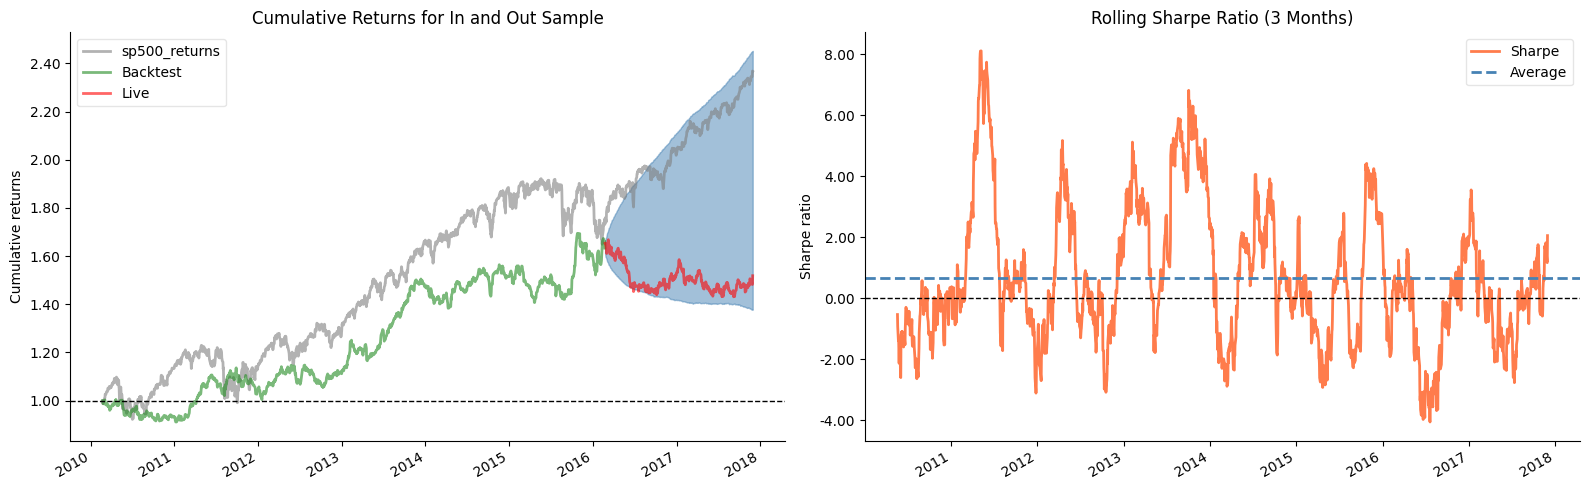

In [45]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))
plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
     
)

plot_rolling_sharpe(
    returns,
    rolling_window=63,
    ax=axes[1]
)

axes[0].set_title("Cumulative Returns for In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

## Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,15.54,2015-10-26,2017-09-07,NaT,NaN
1,11.60,2011-09-28,2012-01-18,2012-04-12,142
2,10.05,2014-11-19,2015-04-22,2015-10-19,239
3,9.27,2010-04-21,2011-01-07,2011-04-08,253
4,8.08,2013-12-12,2014-04-10,2014-07-28,163


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.41%,-2.16%,3.53%
Fukushima,0.16%,-0.59%,0.76%
EZB IR Event,-0.10%,-1.18%,0.99%
Flash Crash,0.28%,0.09%,0.58%
Apr14,0.10%,-1.54%,1.49%
Oct14,0.06%,-1.07%,1.91%
Fall2015,0.05%,-1.26%,1.24%
Recovery,0.02%,-2.87%,3.53%
New Normal,0.03%,-3.82%,4.65%


Top 10 long positions of all time,max
sid,
NFLX,51.17%
URI,22.03%
EXPE,21.23%
NRG,20.87%
VRTX,20.63%
MDT,20.38%
MOH,20.38%
CRM,20.21%
FICO,20.16%


Top 10 short positions of all time,max
sid,
NFLX,-56.30%
MOH,-25.63%
WTW,-25.37%
NRG,-25.37%
BIIB,-20.80%
DXCM,-19.87%
DGX,-19.82%
AMD,-19.76%
ROK,-19.48%


Top 10 positions of all time,max
sid,
NFLX,56.30%
MOH,25.63%
WTW,25.37%
NRG,25.37%
URI,22.03%
EXPE,21.23%
BIIB,20.80%
VRTX,20.63%
MDT,20.38%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$704537.93,$-1010031.52,$1714569.46
Gross profit,$25762076.70,$11775040.91,$13987035.79
Gross loss,$-25057538.77,$-12785072.44,$-12272466.33
Profit factor,$1.03,$0.92,$1.14
Avg. trade net profit,$9.46,$-28.06,$44.52
Avg. winning trade,$694.08,$681.43,$705.10
Avg. losing trade,$-681.60,$-694.31,$-668.84
Ratio Avg. Win:Avg. Loss,$1.02,$0.98,$1.05
Largest winning trade,$80447.79,$39995.49,$80447.79
Largest losing trade,$-37178.25,$-37017.63,$-37178.25


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 13:42:32.556639733,1 days 13:36:52.014253959,1 days 13:47:50.765188493
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,265 days 23:00:00,265 days 23:00:00,147 days 23:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.05%,0.05%,0.05%
Avg returns losing,-0.05%,-0.05%,-0.05%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.03%,0.03%,0.03%
Median returns losing,-0.03%,-0.03%,-0.03%
Largest winning trade,5.15%,2.57%,5.15%
Largest losing trade,-3.04%,-3.04%,-2.68%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,0.01%,-0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.01%,-0.03%,0.00%,0.00%,-0.00%,-0.01%,-0.01%,-0.00%,-0.01%,0.01%,-0.00%,0.02%,0.01%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.01%,-0.00%,-0.01%,0.01%,0.01%,0.01%,0.01%,-0.00%,-0.00%,0.01%,0.00%,0.01%,0.00%,0.00%,0.01%,0.01%,-0.01%,0.01%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.00%,-0.00%,-0.01%,-0.00%,0.00%,0.00%,0.00%,0.01%,-0.01%,-0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.00%,-0.00%,-0.00%,0.00%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.01%,-0.00%,0.00%,-0.00%,-0.00%,0.01%,0.00%,0.00%,-0.00%,0.01%,0.00%,0.01%,-0.00%,0.00%,-0.01%,-0.01%,-0.00%,0.01%,0.00%,-0.00%,0.01%,0.00%,-0.02%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.01%,-0.00%,-0.01%,-0.02%,-0.04%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.01%,-0.00%,-0.00%,-0.00%,0.01%,0.01%,0.00%,-0.01%,0.00%,0.00%,-0.01%,-0.00%,0.01%,0.01%,0.01%,0.01%,0.01%,0.02%,0.01%,0.00%,0.00%,0.01%,0.00%,-0.01%,0.00%,0.01%,0.00%,0.02%,0.00%,0.00%,0.00%,0.00%,-0.02%,0.01%,0.00%,0.00%,0.00%,0.00%,-0.00%,-0.02%,-0.00%,0.00%,-0.00%,0.01%,-0.02%,-0.00%,0.00%,0.00%,0.00%,-0.02%,0.00%,0.00%,0.01%,0.00%,0.00%,0.01%,-0.00%,0.00%,-0.00%,0.01%,-0.01%,-0.00%,-0.01%,0.00%,-0.00%,0.00%,-0.00%,-0.01%,-0.00%,-0.01%,0.00%,-0.01%,0.00%,0.01%,-0.00%,0.00%,0.01%,0.01%,0.00%,-0.00%,-0.00%,0.02%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,-0.01%,-0.00%,-0.00%,0.01%,0.00%,-0.01%,-0.00%,0.01%,0.01%,-0.00%,0.01%,0.01%,0.01%,0.00%,0.02%,-0.00%,0.01%,0.00%,-0.00%,0.01%,0.01%,0.01%,0.00%,0.00%,0.01%,0.02%,-0.00%,0.01%,0.00%,-0.02%,-0.00%,-0.01%,0.00%,-0.00%,0.01%,0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.01%,0.01%,-0.00%,-0.00%,0.00%,0.01%,0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.01%,-0.01%,0.00%,0.01%,0.00%,-0.01%,-0.01%,0.00%,-0.00%,-0.00%,-0.01%,-0.01%,0.01%,-0.00%,-0.00%,0.02%,0.01%,0.00%,0.01%,0.00%,-0.03%,0.01%,0.00%,-0.00%,0.00%,0.00%,0.00%,0.01%,-0.00%,0.00%,-0.01%,-0.01%,-0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,0.01%,0.01%,0.01%,-0.00%,-0.00%,0.00%,0.00%,0.01%,0.01%,-0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,0.01%,0.01%,0.00%,-0.00%,0.00%,-0.01%,0.01%,0.01%,0.00%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.01%,-0.02%,-0.01%,0.01%,0.01%,-0.02%,-0.00%,0.00%,0.01%,0.01%,-0.00%,-0.01%,0.00%,0.00%,0.01%,0.02%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,0.01%,0.00%,-0.00%,-0.00%,0.01%,0.01%,-0.00%
Avg returns winning,0.06%

Profitability (PnL / PnL total) per name,
symbol,
NFLX,9.82%
WMB,9.58%
BBY,8.70%
REGN,7.00%
MNST,6.84%
BIIB,6.44%
GIS,5.88%
NEM,5.83%
LVS,5.44%


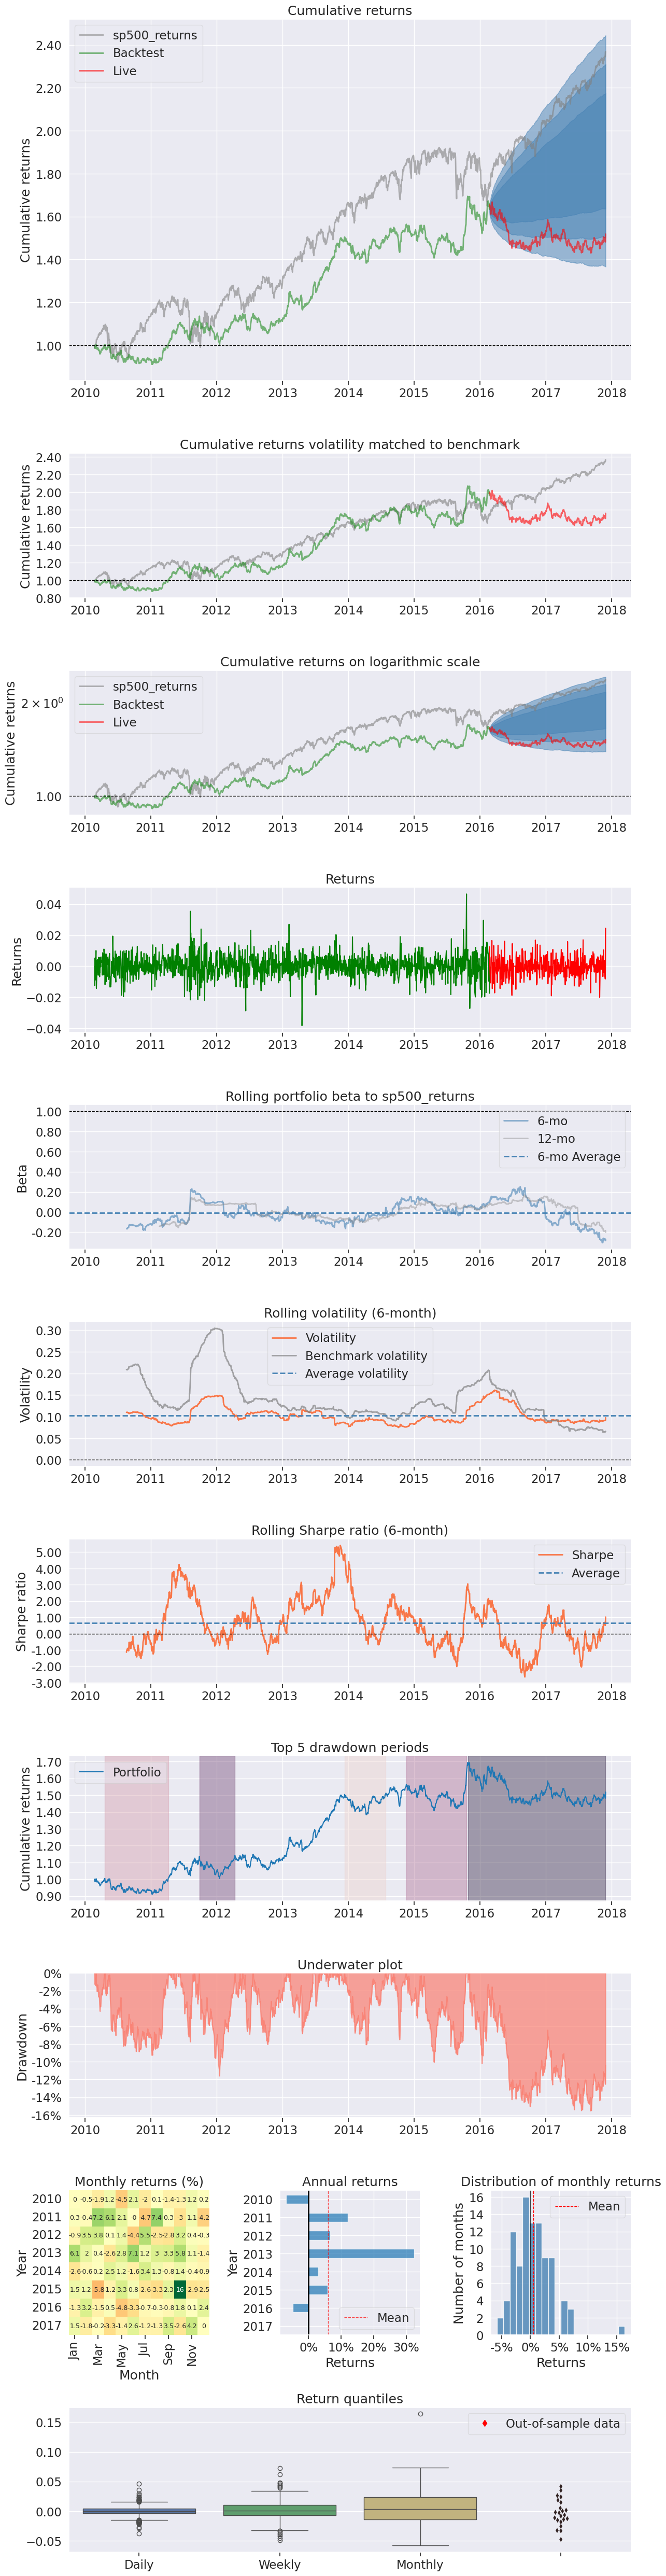

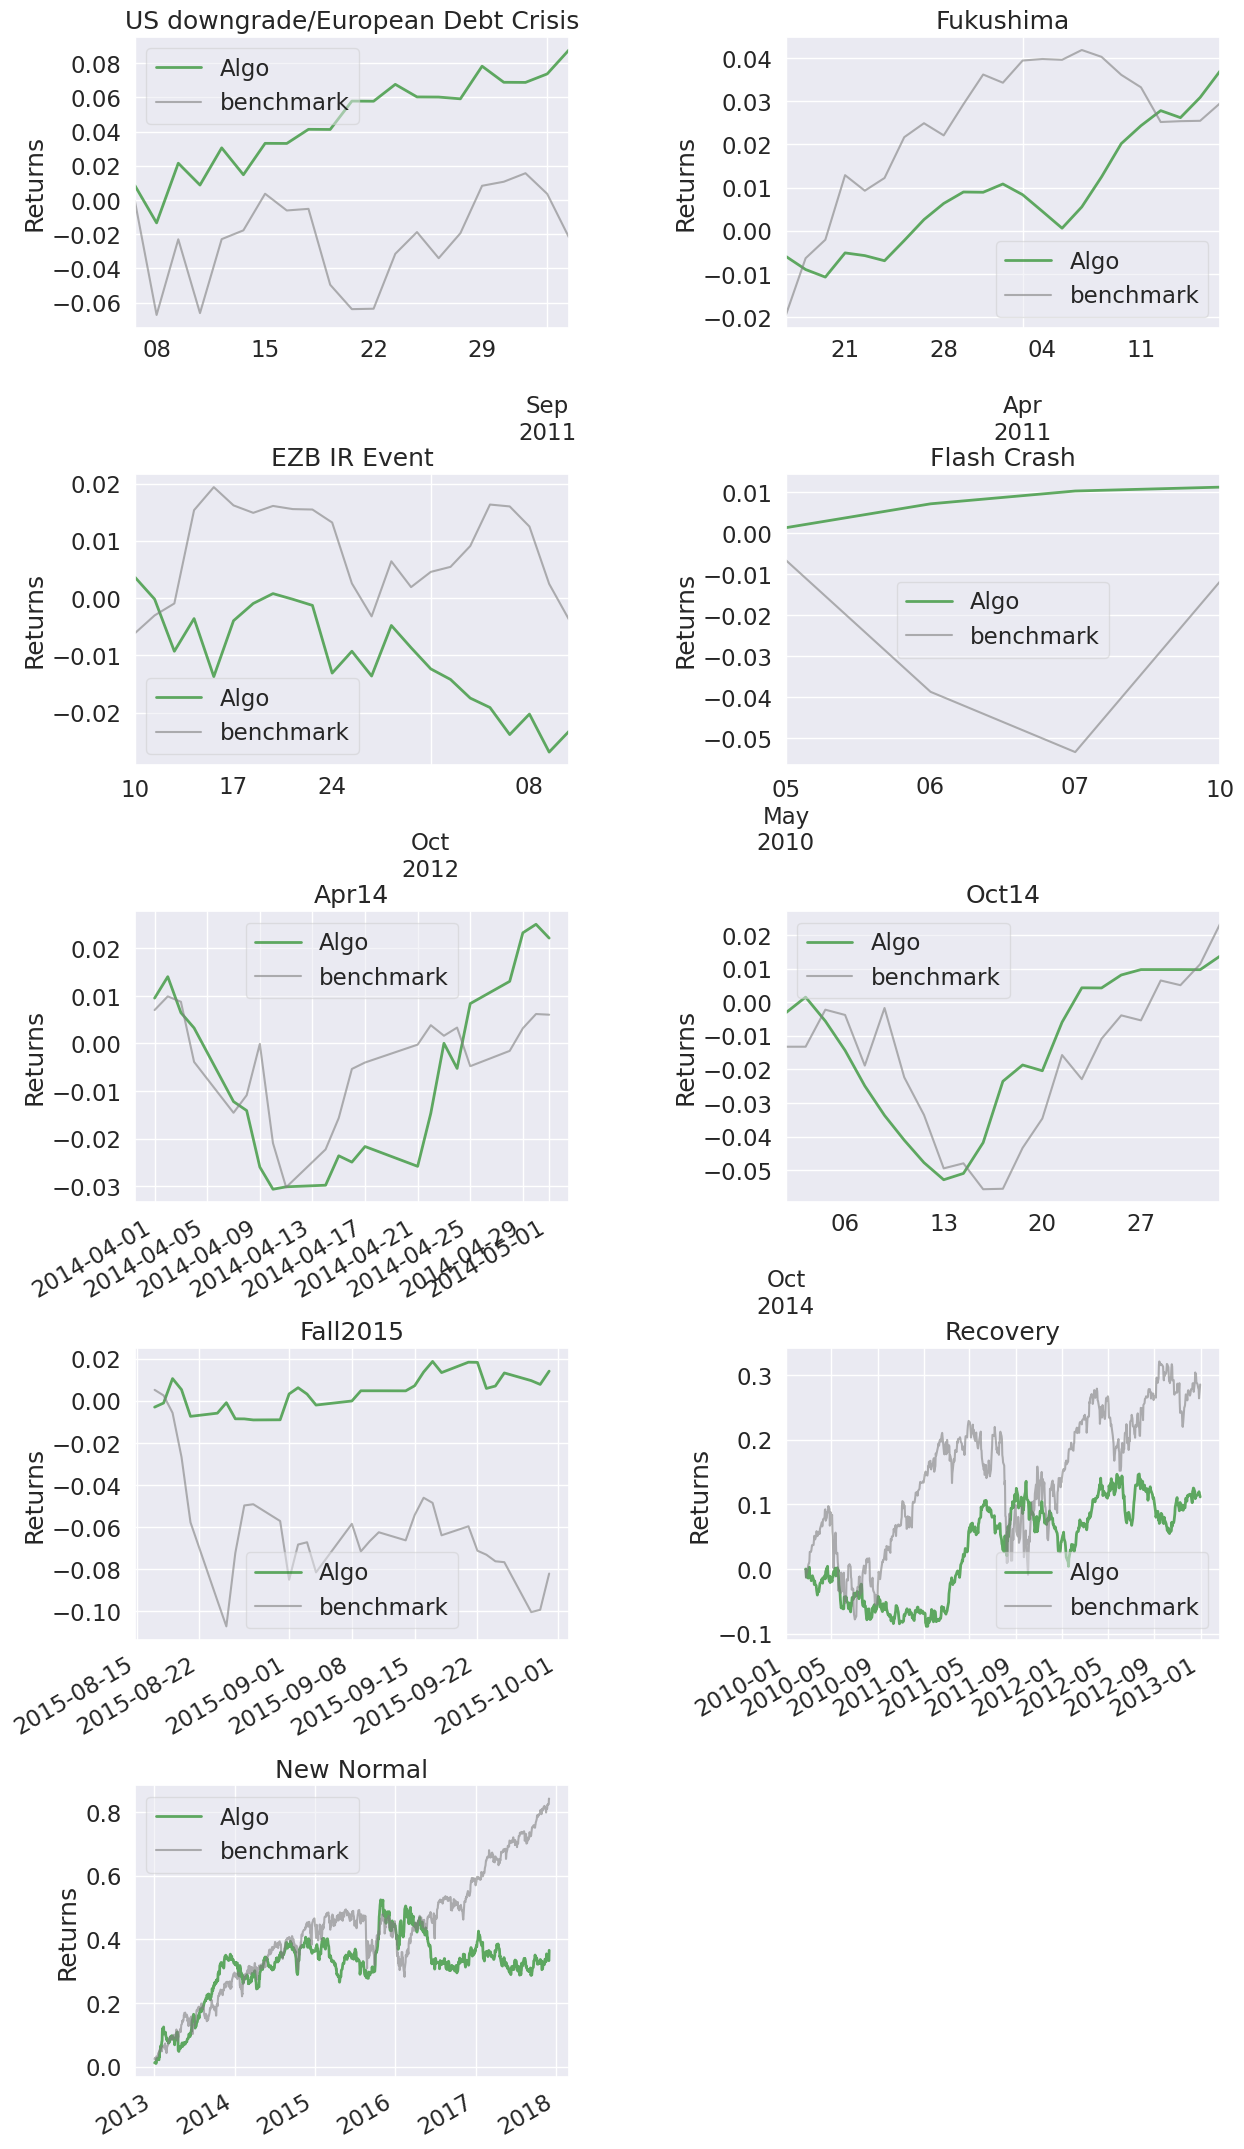

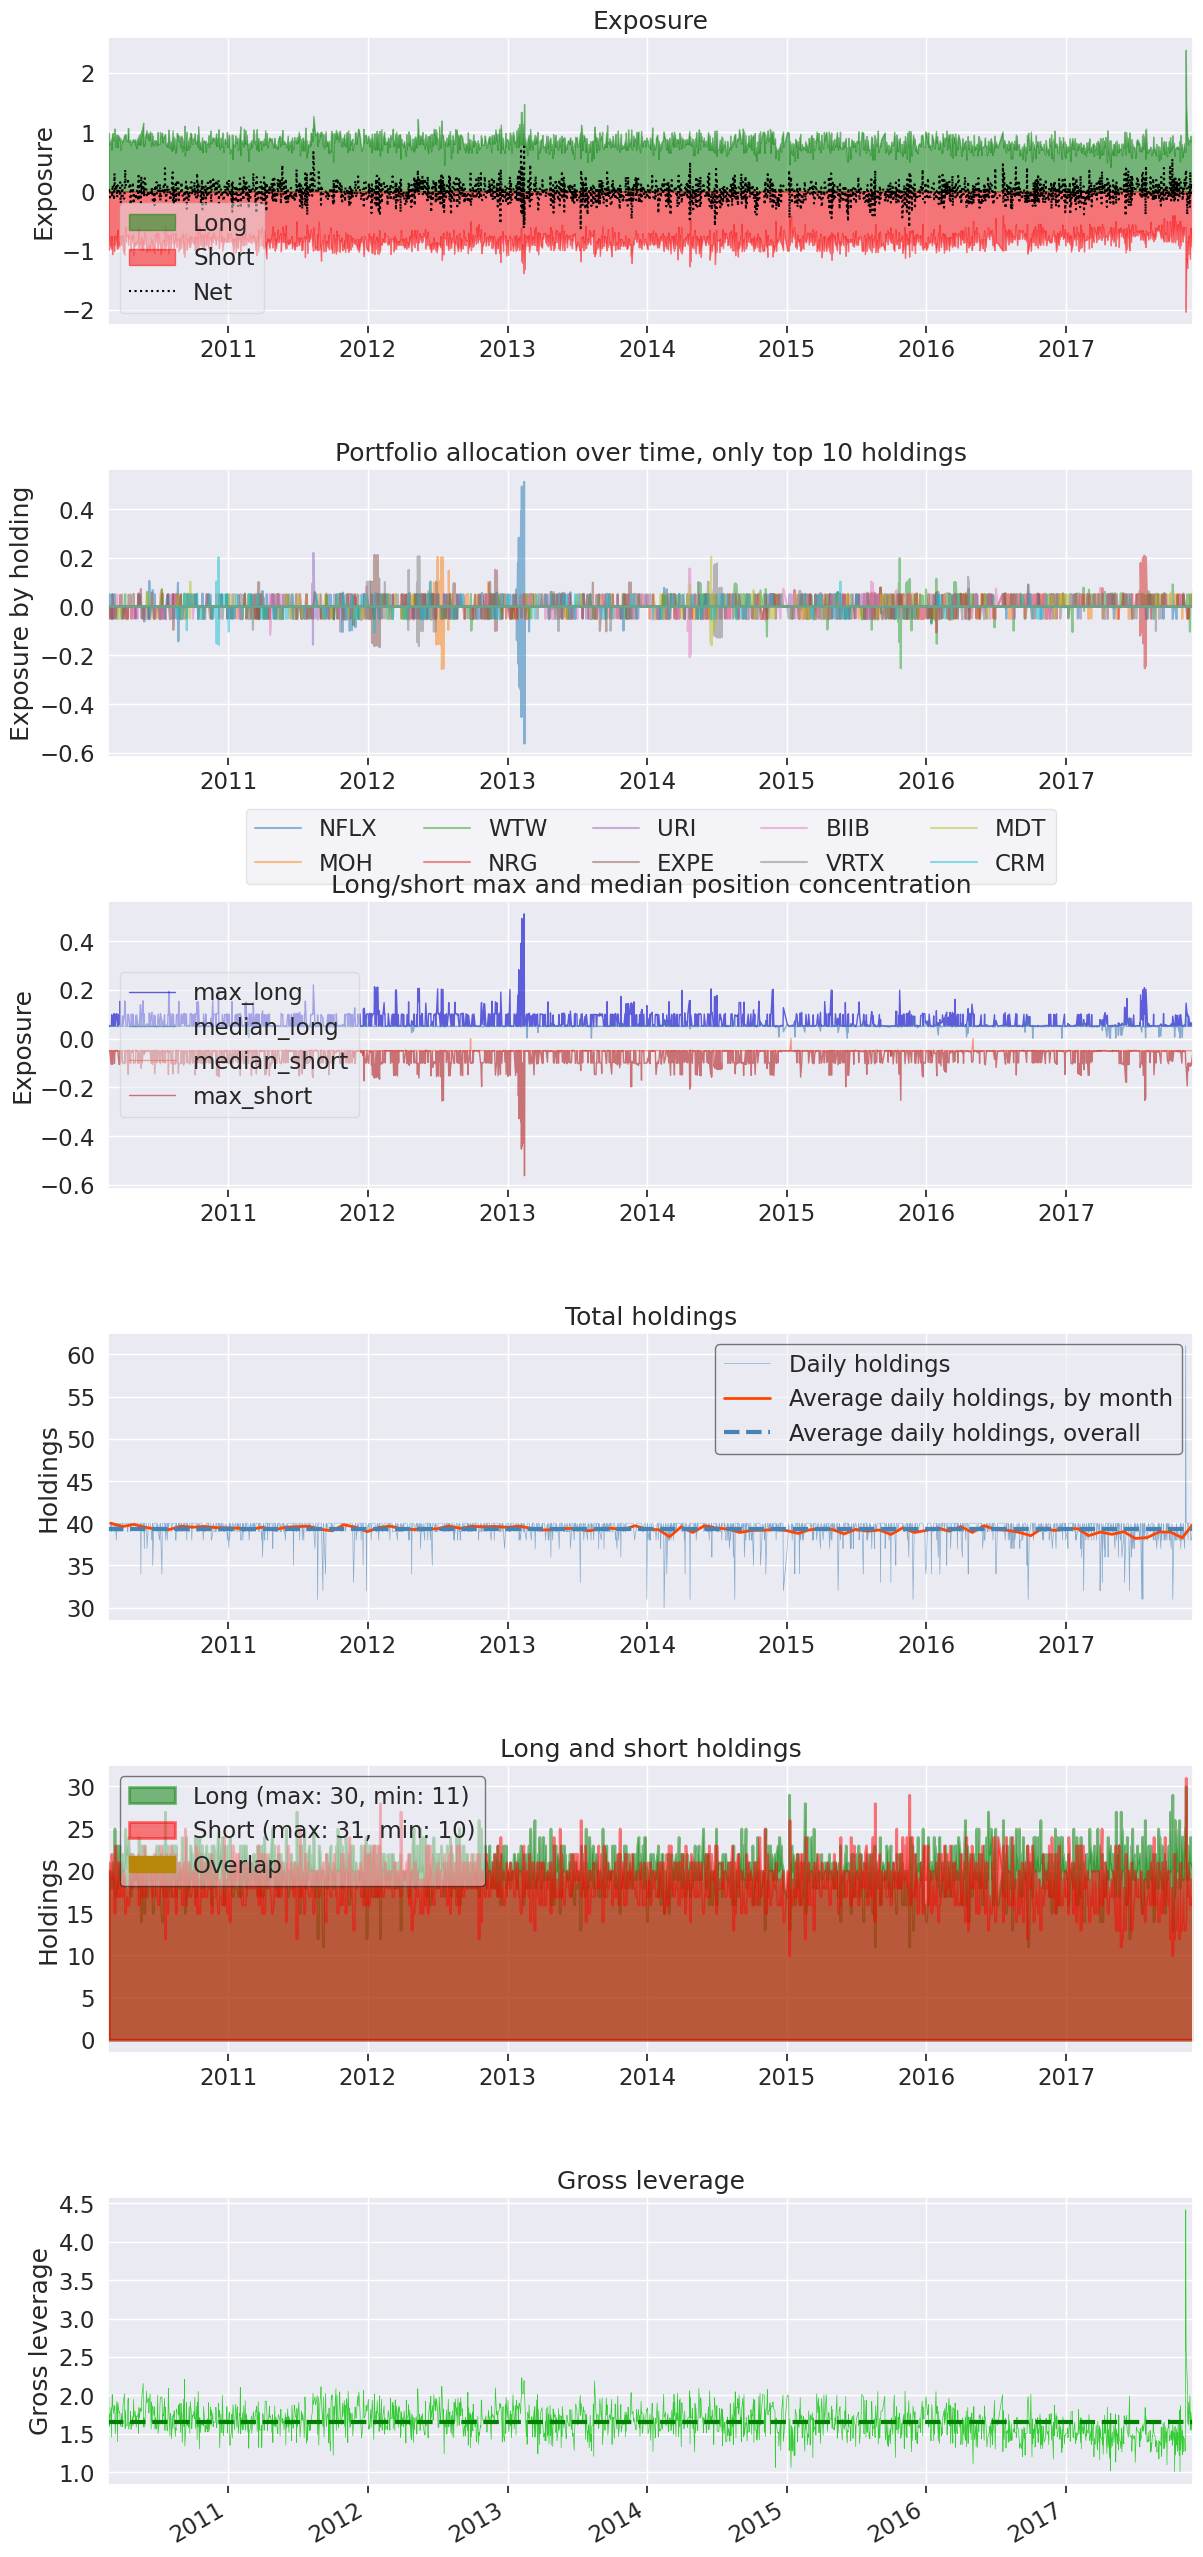

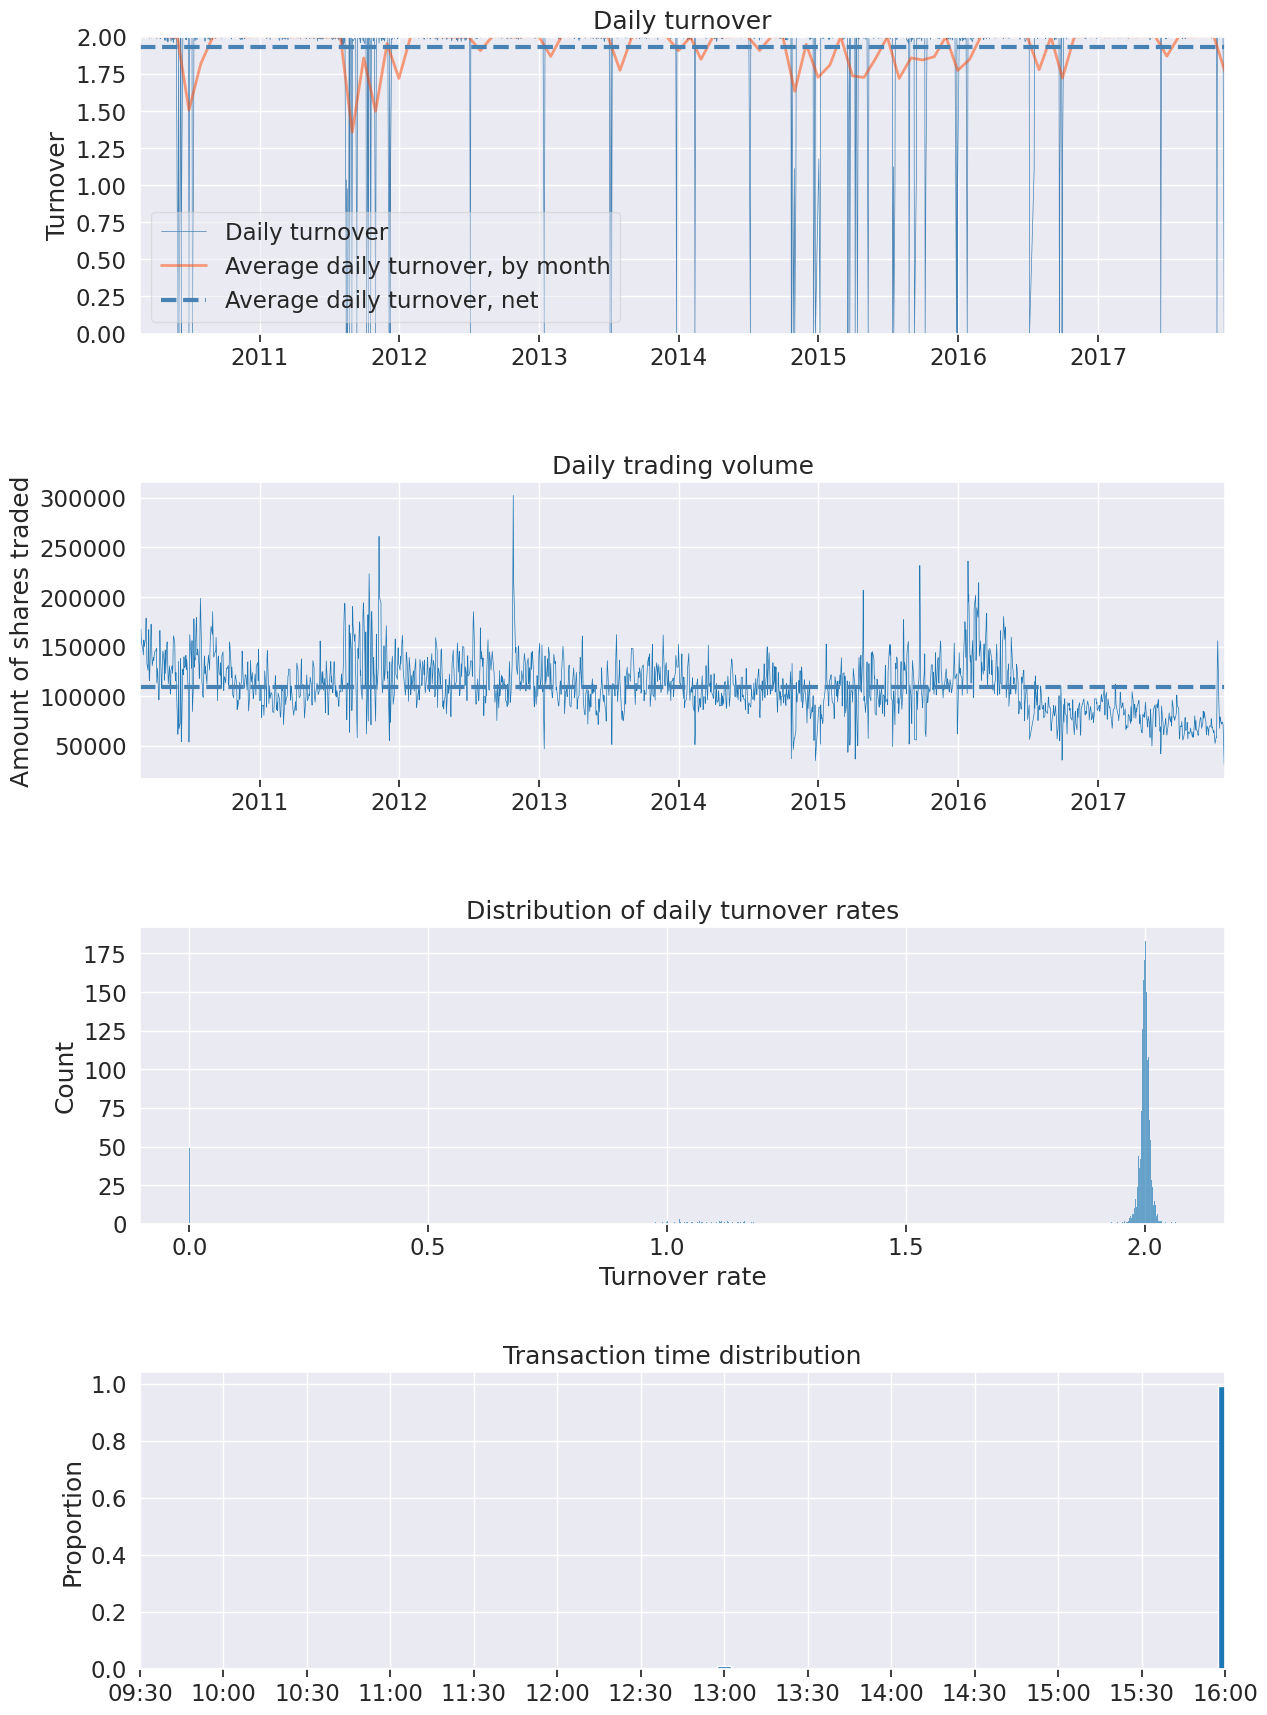

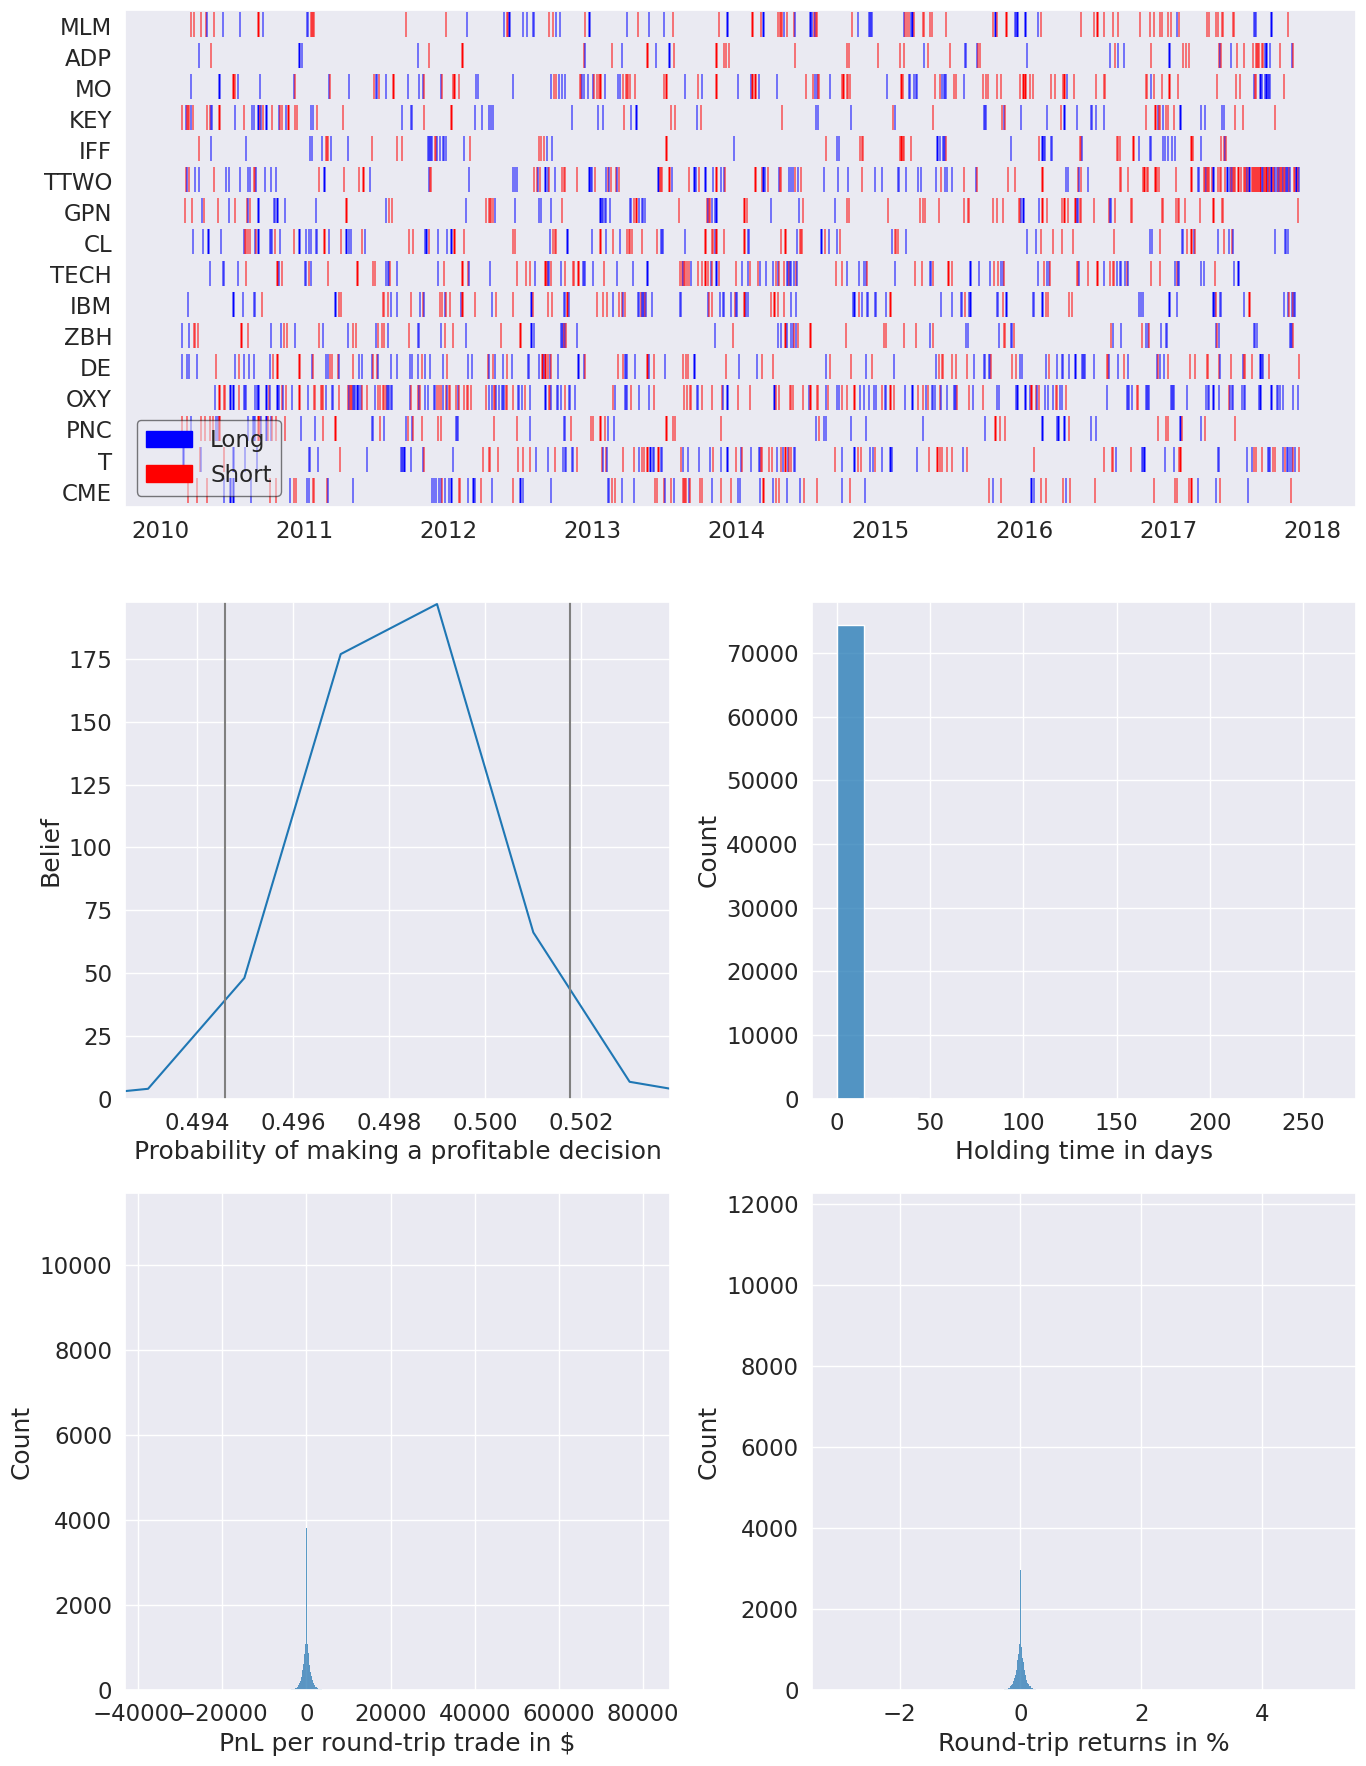

In [46]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)